In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import ConcreteModel, Set, Param, Var, Objective, Constraint, SolverFactory, NonNegativeReals, minimize, Reals, Binary, value, RangeSet
from pyomo.environ import *
import gurobipy as grb

# Decision Making Project Part A

## Data

In [55]:
Occ_r1 = pd.read_csv("occupancyRoom1.csv")
Occ_r2 = pd.read_csv("occupancyRoom2.csv")
price = pd.read_csv("priceData.csv")

print (Occ_r1.tail)
print (Occ_r2.tail())

<bound method NDFrame.tail of     0                   1                   2                  \
0           32.969098           34.098942           33.617007   
1           25.734241           22.844536           28.601731   
2           27.721293           26.389921           27.307564   
3           32.269034           33.350905           30.622932   
4           31.365328           31.633592           36.351464   
..                ...                 ...                 ...   
95          32.571571           31.559716           26.734933   
96          30.951060           32.699171           29.511854   
97          25.746245           27.247556           26.288097   
98          32.365572           36.255570           36.204028   
99          30.816083           30.554202           33.584646   

     3                   4                   5                  \
0            35.445151           32.503181           30.244813   
1            24.350131           34.476828           32.2

In [56]:
def get_fixed_data():
    """
    Returns the fixed data for the heating + ventilation system.
    THIS CODE SHOULD NOT BE CHANGED BY STUDENTS.
    """

    # ------------------------------
    # Simulation settings
    # ------------------------------

    num_timeslots = 10  # number of discrete simulation steps (hours)


    return {

        # Number of timeslots (hours)
        'num_timeslots': num_timeslots,


        # ------------------------------
        # Initial indoor conditions
        # ------------------------------
        'initial_temperature': 21.0,
        'previous_initial_temperature': 21.0,
        'initial_humidity': 40.0,


        # ------------------------------
        # Heating system parameters
        # ------------------------------

        # Maximum heating power (kW)
        # Heater can output between 0 and this value.
        'heating_max_power': 3.0, # P(r)max

        # Heat exchange coefficient between rooms
        # (°C change per hour per °C difference between rooms)
        'heat_exchange_coeff': 0.6, # Zexch

        # Heating efficiency:
        # Increase in room temperature per kW of heating power (°C per hour per kW)
        'heating_efficiency_coeff': 1.0, #Zconv

        # Thermal loss coefficient:
        # Fraction of indoor-outdoor temperature difference lost per hour
        # (°C change per hour per °C difference between inddors and outdoors temperature)
        'thermal_loss_coeff': 0.1, #Zloss

        # Ventilation cooling effect:
        # Temperature decrease in the room for each hour that ventilation is ON (°C)
        'heat_vent_coeff': 0.7, #Zcool

        # Occupancy heat gain:
        # Temperature increase per hour per person in the room (°C)
        'heat_occupancy_coeff': 0.02, #Zocc


        # ------------------------------
        # Comfort and control thresholds (°C)
        # ------------------------------

        # Lower threshold for Overrule heater activation
        'temp_min_comfort_threshold': 18.0, #Tmin

        # Temperature above which the Overrule controller is deactived
        'temp_OK_threshold': 22.0, #Tok

        # Hard upper limit: when exceeded, heater must be OFF
        'temp_max_comfort_threshold': 26.0, #Thigh


        # ------------------------------
        # Outdoor temperature (°C)
        # Known “in hindsight” time series provided to the MILP.
        # A simple sinusoidal profile is used as an example.
        # ------------------------------

        'outdoor_temperature': [
            3 * np.sin(2 * np.pi * t / num_timeslots - np.pi/2)
            for t in range(num_timeslots)
        ], # Tout


        # ------------------------------
        # Ventilation system parameters
        # ------------------------------

        # Minimum number of consecutive hours that ventilation must remain ON
        # after being started
        'vent_min_up_time': 3, #3 hour ventilation time

        # Humidity threshold above which overrule controller forces ventilation ON (%)
        'humidity_threshold': 70.0, #Hhigh

        # Electrical power consumption of ventilation when ON (kW)
        'ventilation_power': 2.0, # Pvent
        
        # Degrees of humidity increase per hour per person
        'humidity_occupancy_coeff':0.18, #Nocc
        
        # Degrees of humidity decrease per hour that ventilation is ON
        'humidity_vent_coeff': 15 #Nvent
        
    }

In [57]:
data_fixed = get_fixed_data()
print(data_fixed)

{'num_timeslots': 10, 'initial_temperature': 21.0, 'previous_initial_temperature': 21.0, 'initial_humidity': 40.0, 'heating_max_power': 3.0, 'heat_exchange_coeff': 0.6, 'heating_efficiency_coeff': 1.0, 'thermal_loss_coeff': 0.1, 'heat_vent_coeff': 0.7, 'heat_occupancy_coeff': 0.02, 'temp_min_comfort_threshold': 18.0, 'temp_OK_threshold': 22.0, 'temp_max_comfort_threshold': 26.0, 'outdoor_temperature': [np.float64(-3.0), np.float64(-2.4270509831248424), np.float64(-0.9270509831248421), np.float64(0.9270509831248421), np.float64(2.4270509831248424), np.float64(3.0), np.float64(2.4270509831248424), np.float64(0.9270509831248426), np.float64(-0.9270509831248419), np.float64(-2.427050983124842)], 'vent_min_up_time': 3, 'humidity_threshold': 70.0, 'ventilation_power': 2.0, 'humidity_occupancy_coeff': 0.18, 'humidity_vent_coeff': 15}


## Creating Variables and Parameters

In [58]:
# Variables
# Create Pyomo model
model = ConcreteModel()
day = 0
# Sets 
model.R = Set(initialize=[1, 2])  # Rooms
model.T = Set(initialize=range(data_fixed['num_timeslots'])) #Time steps
model.D = Set(initialize=range(Occ_r1.shape[0])) # Days (for occupancy data)
model.TD = model.T * model.D # Time-Day combinations
model.RTD = model.R*model.T*model.D # Room-Time-Day combinations


#Parameters
model.Pr = Param(initialize=data_fixed['heating_max_power']) # Maximum heating power (kW)
model.Zexch = Param(initialize=data_fixed['heat_exchange_coeff']) # Heat exchange coefficient between rooms
model.Zconv = Param(initialize=data_fixed['heating_efficiency_coeff']) # Heating efficiency
model.Zloss = Param(initialize=data_fixed['thermal_loss_coeff']) # Thermal loss coefficient
model.Zcool = Param(initialize=data_fixed['heat_vent_coeff']) # Ventilation cooling effect
model.Zocc = Param(initialize=data_fixed['heat_occupancy_coeff']) # Occupancy
model.Tmin = Param(initialize=data_fixed['temp_min_comfort_threshold']) # Lower threshold for Overrule heater activation
model.Tok = Param(initialize=data_fixed['temp_OK_threshold']) # Temperature above which the Overrule controller is deactived
model.Thigh = Param(initialize=data_fixed['temp_max_comfort_threshold']) # Hard upper limit: when exceeded, heater must be OFF
model.Hhigh = Param(initialize=data_fixed['humidity_threshold']) # Humidity threshold above which overrule controller forces ventilation ON (%)
model.Pvent = Param(initialize=data_fixed['ventilation_power']) # Electrical power consumption of ventilation when ON (kW)
model.Hocc = Param(initialize=data_fixed['humidity_occupancy_coeff']) # Degrees of humidity increase per hour per person
model.Hvent = Param(initialize=data_fixed['humidity_vent_coeff']) # Degrees of humidity decrease per hour that ventilation is ON
model.Tout = Param(model.T, initialize={t: data_fixed['outdoor_temperature'][t] for t in model.T}) # Outdoor temperature (°C)


# Variables
model.Vent = Var(model.TD, domain=Binary) # Ventilation ON/OFF
model.Uon = Var(model.TD, domain=Binary) # Ventilation start-up
model.Uoff = Var(model.TD, domain=Binary) # Ventilation shut-down
model.Heat = Var(model.RTD, domain=NonNegativeReals, bounds=(0, model.Pr)) # Heating power (kW)
model.w = Var(model.RTD, domain=Binary) # T is higher thatn Tok
model.u = Var(model.RTD, domain=Binary) # T is lower than Tlow
model.z = Var(model.RTD, domain=Binary) # T is lower than Tok
model.y = Var(model.RTD, domain=Binary) # T is higher than Thigh
model.T_in = Var(model.RTD, domain=NonNegativeReals) # Indoor temperature (°C)
model.Hum = Var(model.TD, domain=NonNegativeReals) # Indoor humidity (%)




In [59]:
# Print the values of Tout (outdoor temperature parameter)
print('Tout values:')
for t in model.T:
    print(f'Time {t}:', value(model.Tout[t]))

Tout values:
Time 0: -3.0
Time 1: -2.4270509831248424
Time 2: -0.9270509831248421
Time 3: 0.9270509831248421
Time 4: 2.4270509831248424
Time 5: 3.0
Time 6: 2.4270509831248424
Time 7: 0.9270509831248426
Time 8: -0.9270509831248419
Time 9: -2.427050983124842


## Add Objective Function


In [60]:
prices = pd.read_csv("priceData.csv")
prices_dict = {}
for day_idx, row in prices.iterrows():
    for hour in prices.columns:
        prices_dict[(day_idx, int(hour))] = row[hour]
model.prices = Param(model.D, model.T, initialize=prices_dict)

def total_cost_rule(model):
    heat_cost = sum(model.prices[d, t] * model.Heat[r, t, d] for r in model.R for t in model.T for d in model.D)
    vent_cost = sum(model.prices[d, t] * model.Vent[t, d] * model.Pvent for t in model.T for d in model.D)
    return heat_cost + vent_cost

model.obj = Objective(rule=total_cost_rule, sense=minimize)


## Adding constraints

In [61]:
#Constraint of room temperature and humidity dynamics for room and room 2

def room_thermal_balance_rule(model, r, t, d):
    # Innitialize the first time step with the initial temperature value
    if t == model.T.first():
        return model.T_in[r, t, d] == data_fixed['initial_temperature'] #average initial temperature value
    
    # Define the previous time step
    # This works if model.T is a Set of sequential integers
    t_prev = t - 1 
    
    # Get occupancy value using iloc for row 0, column t_prev (time index)
    occupancy_value1 = Occ_r1.iloc[d, t_prev]
    occupancy_value2 = Occ_r2.iloc[d, t_prev]

    if r > 1: 
        room1 = 1
        room2 = 2
    else:
        room1 = 2
        room2 = 1
    
    if r == 1:
        occupancy = occupancy_value1
    else:
        occupancy = occupancy_value2


    # The Equation: T_now = T_prev + Internal_Exchange + External_Loss + Heating
    return model.T_in[r, t, d] == (
        model.T_in[r, t_prev, d] 
         + model.Zexch * (model.T_in[room1, t_prev, d] - model.T_in[room2, t_prev, d]) 
         + model.Zloss * (model.Tout[t_prev] - model.T_in[r, t_prev, d])
        + model.Zconv * (model.Heat[r, t_prev, d]) 
         - model.Zcool * model.Vent[t_prev, d]
         + model.Zocc * occupancy
    )


def humidity_balance_rule(model, t, d):
    # Initialize the first time step with the initial humidity value
    if t == model.T.first():
        return model.Hum[t, d] == data_fixed['initial_humidity'] #average initial humidity value
    
    # Define the previous time step
    t_prev = t - 1
    
    return model.Hum[t, d] == (
        model.Hum[t_prev, d]
        - model.Hvent * model.Vent[t_prev, d]
        + model.Hocc * (Occ_r1.iloc[d, t_prev] + Occ_r2.iloc[d, t_prev])
    )

# Apply the rule to the model across all time steps
model.Temp_Room_Dynamics = Constraint(model.RTD, rule=room_thermal_balance_rule)
model.Hum_Room_Dynamics = Constraint(model.TD, rule=humidity_balance_rule)


In [62]:
# Max Temperature when temperature is too low 
def max_temp_low_rule(block):

    # M is a large constant, larger than any possible temperature difference
    M = 100 
    m = block.model()

    # Constraint to force u = 1 if T_in <= Tmin
    def u_binary_logic_rule(block, r, t, d):
        return m.T_in[r, t, d] >= m.Tmin - M * m.u[r, t, d]
    block.u_logic = Constraint(m.RTD, rule=u_binary_logic_rule)

    # Force Heat to Max if w = 1
    def low_temp_heat_rule(block, r, t, d):
        return m.T_in[r, t, d] >= m.Tok - M * (1 - m.w[r, t, d])
    block.low_temp_heat = Constraint(m.RTD, rule=low_temp_heat_rule)

    # cannot have both u and w active at the same time
    def u_w_exclusivity_rule(block, r, t, d):    
        # Skip the first time step (initial condition)
        if t == m.T.first():
            m.u[r, t, d].fix(0)  # Force u to be 0 at the first time step
            m.w[r, t, d].fix(0)  # Force w to be 0 at the first time step
            return Constraint.Skip # Skip because initialized conditions are within Tlow and THigh at the first time step
        
        # Define the previous time step
        t_prev = t - 1

        return m.u[r, t, d] >= m.u[r,t_prev, d] - m.w[r, t, d]
    block.u_w_exclusivity = Constraint(m.RTD, rule=u_w_exclusivity_rule)

    #Set P to P max 
    def Set_max_power_rule(block, r, t, d):
        return m.Heat[r, t, d] >= m.Pr * m.u[r, t, d]
    block.Set_max_power = Constraint(m.RTD, rule=Set_max_power_rule)

    
model.set_max_temp_rule = Block(rule=max_temp_low_rule)

In [63]:
def set_power_off_rule(block):
    # M is a large constant (Big-M)
    M = 100 
    m = block.model()

    # Constraint to force y = 1 if T_in >= Thigh
    # If T_in > Thigh, then y must be 1 to satisfy: T_in <= Thigh + M*y
    def y_binary_logic_rule(block, r, t, d):
        return m.T_in[r, t, d] <= m.Thigh + M * m.y[r, t, d]
    block.y_logic = Constraint(m.RTD, rule=y_binary_logic_rule)

    # Force Heat to 0 if y = 1
    # If y = 1, Heat <= Pr * (1 - 1) => Heat <= 0
    # If y = 0, Heat <= Pr * (1 - 0) => Heat <= Pr (normal operation)
    def Set_power_off_rule(block, r, t, d):
        return m.Heat[r, t, d] <= m.Pr * (1 - m.y[r, t, d])
    block.Set_power_off = Constraint(m.RTD, rule=Set_power_off_rule)

# Apply the block to the model
model.set_power_off_rule = Block(rule=set_power_off_rule)

In [64]:
def set_vent_on_rule(model,t,d):
    # Force Vent ON if Hum >= Hhigh
    M = 100
    return model.Hum[t, d] <= model.Hhigh + M * model.Vent[t, d]

model.vent_on_rule = Constraint(model.TD, rule=set_vent_on_rule)

In [65]:
#Operational constraints for ventilation system
def on_off_limit_rule(model, t, d):
    return model.Uon[t, d] + model.Uoff[t, d] <= 1
model.on_off_limit = Constraint(model.TD, rule=on_off_limit_rule)

# Constraint 2: U_off <= e
def off_le_e_rule(model, t, d):
    return model.Uoff[t, d] <=1 - model.Vent[t, d]
model.off_le_e = Constraint(model.TD, rule=off_le_e_rule)

# Constraint 3: U_on <= 1 - e
def on_le_one_minus_e_rule(model, t, d):
    return model.Uon[t, d] <= model.Vent[t, d]
model.on_le_one_minus_e = Constraint(model.TD, rule=on_le_one_minus_e_rule)

In [66]:
def set_vent_inertia_rule(model,t,d):
   if t == model.T.first():

      return Constraint.Skip # Skip because there is no previous time step at the first time step
   # Define the previous time step
   t_prev = t - 1
   return model.Uon[t, d] >= model.Vent[t, d] - model.Vent[t_prev, d]
model.vent_inertia_rule = Constraint(model.TD, rule=set_vent_inertia_rule)


### check that this funciton is working
def min_up_time_ventilation_rule(model, t, d):
    # We can't check 't-1' for the very first hour
    #if t == model.T.first():
        #return Constraint.Skip
    
    # Define the 'Up-Time' duration
    L = 3 
    
    # If we are too close to the end of the day to look L steps ahead,
    # we adjust the summation range to not exceed the time set.
    remaining_steps = [k for k in range(t, t + L) if k <= model.T.last()]
    #if t = 0 assume ventilation was off in the previous hour
    v_prev = model.Vent[t-1, d] if t > model.T.first() else 0

    # Logic: Sum of future states >= duration * (Current - Previous)
    return sum(model.Vent[k, d] for k in remaining_steps) >= \
           len(remaining_steps) * (model.Vent[t, d] - v_prev)

model.min_vent_on = Constraint(model.T, model.D, rule=min_up_time_ventilation_rule)

In [67]:
'''
# Max Temperature when temperature is too low
def low_to_max_temp_rule(model, t, r, d):
    if model.T_in[r, t, d] <= model.Tmin:
        return model.Heat[r, t, d] == model.Pr

# Power off when temperature is too high
def high_to_zero_temp_rule(model, t, r, d):
    if model.T_in[r, t, d] >= model.Thigh:
        return model.Heat[r, t, d] == 0
    
# High humidity forces ventilation ON
def high_humidity_ventilation_rule(model, t, d):
    if model.Hum[t, d] >= model.Hhigh:
        return model.Vent[t, d] == 1

'''

'\n# Max Temperature when temperature is too low\ndef low_to_max_temp_rule(model, t, r, d):\n    if model.T_in[r, t, d] <= model.Tmin:\n        return model.Heat[r, t, d] == model.Pr\n\n# Power off when temperature is too high\ndef high_to_zero_temp_rule(model, t, r, d):\n    if model.T_in[r, t, d] >= model.Thigh:\n        return model.Heat[r, t, d] == 0\n\n# High humidity forces ventilation ON\ndef high_humidity_ventilation_rule(model, t, d):\n    if model.Hum[t, d] >= model.Hhigh:\n        return model.Vent[t, d] == 1\n\n'

### optimization test


In [68]:

# 1. Select the solver 
solver = SolverFactory('gurobi') 

# 2. Solve the model
results = solver.solve(model, tee=True) # tee=True shows the solver's internal logs

model.write("model.lp", io_options={'symbolic_solver_labels': True})

# 3. Check the Termination Condition
from pyomo.opt import TerminationCondition

if results.solver.termination_condition == TerminationCondition.optimal:
    print("Success: Optimal solution found!")
    model.pprint()

elif results.solver.termination_condition == TerminationCondition.infeasible:
    print("Failure: The model is infeasible (the constraints contradict each other).")
else:
    print(f"Solver Status: {results.solver.termination_condition}")

Read LP format model from file C:\Users\mauri\AppData\Local\Temp\tmp0u9lg_5p.pyomo.lp
Reading time = 0.08 seconds
x1: 20700 rows, 13600 columns, 50800 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 20700 rows, 13600 columns and 50800 nonzeros (Min)
Model fingerprint: 0x418a6538
Model has 2988 linear objective coefficients
Variable types: 5000 continuous, 8600 integer (8600 binary)
Coefficient statistics:
  Matrix range     [3e-01, 1e+02]
  Objective range  [3e-02, 2e+01]
  Bounds range     [1e+00, 3e+00]
  RHS range        [8e-04, 8e+01]

Presolve removed 15727 rows and 9763 columns (presolve time = 5s)...
Presolve removed 20589 rows and 13514 columns
Presolve time: 7.85s
Presolved: 111 rows, 86 columns, 334 nonzeros
Variable types: 38 continuous, 48 integer (4

### Extraction and Formatted Results Output

In [69]:
if results.solver.termination_condition == TerminationCondition.optimal:
    print("\n" + "="*80)
    print("      MILP OPTIMIZATION RESULTS - TASK 1 (Optimal in Hindsight)")
    print("="*80)
    
    # 1. Calculation of the Objective Values
    total_cost = value(model.obj)
    avg_daily_cost = total_cost / 100
    
    print(f"{'Total Cost (100 days):':<40} {total_cost:,.2f} DKK")
    print(f"{'AVERAGE DAILY COST:':<40} {avg_daily_cost:.2f} DKK")
    print("-" * 80)

    # 2. Daily Operational Detail (Select a day, e.g., d=99)
    # You can change d to compare different scenarios (e.g., high vs low price days)
    d = 99
    T = list(model.T)
    
    data_summary = {
        "Hour": T,
        "Price[DKK/kWh]": [round(value(model.prices[d, t]), 3) for t in T],
        "Occ_R1": [int(Occ_r1.iloc[d, t]) for t in T],
        "Occ_R2": [int(Occ_r2.iloc[d, t]) for t in T],
        "Temp_R1[°C]": [round(value(model.T_in[1, t, d]), 2) for t in T],
        "Temp_R2[°C]": [round(value(model.T_in[2, t, d]), 2) for t in T],
        "Heat_R1[kW]": [round(value(model.Heat[1, t, d]), 2) for t in T],
        "Heat_R2[kW]": [round(value(model.Heat[2, t, d]), 2) for t in T],
        "Hum[%]": [round(value(model.Hum[t, d]), 1) for t in T],
        "Vent[State]": [int(value(model.Vent[t, d])) for t in T]
    }

    df_res = pd.DataFrame(data_summary)
    
    print(f"\nOperational Log - Day {d}:")
    # Using to_string for a clean, non-truncated table
    print(df_res.to_string(index=False))
    print("-" * 80)

    # 3. Overrule Controller Verification
    # Logic check: Did the overrules trigger as expected?
    high_hum_triggered = [t for t in T if value(model.Hum[t, d]) >= 70.0]
    if high_hum_triggered:
        print(f"CHECK: Humidity Overrule active at hours: {high_hum_triggered}")
    
    low_temp_triggered = [t for t in T if any(value(model.T_in[r, t, d]) <= 18.001 for r in model.R)]
    if low_temp_triggered:
        print(f"CHECK: Low Temp Overrule active at hours: {low_temp_triggered}")

    high_temp_triggered = [t for t in T if any(value(model.T_in[r, t, d]) >= 25.999 for r in model.R)]
    if high_temp_triggered:
        print(f"CHECK: High Temp Overrule (Heater OFF) active at hours: {high_temp_triggered}")

    print("="*80)

else:
    print("Error: Solver did not find an optimal solution.")


      MILP OPTIMIZATION RESULTS - TASK 1 (Optimal in Hindsight)
Total Cost (100 days):                   11,157.07 DKK
AVERAGE DAILY COST:                      111.57 DKK
--------------------------------------------------------------------------------

Operational Log - Day 99:
 Hour  Price[DKK/kWh]  Occ_R1  Occ_R2  Temp_R1[°C]  Temp_R2[°C]  Heat_R1[kW]  Heat_R2[kW]  Hum[%]  Vent[State]
    0           2.309      30      21        21.00        21.00         0.00         0.00    40.0            1
    1           1.191      30      23        18.52        18.32         3.00         3.00    34.3            1
    2           1.534      33      26        19.22        19.13         3.00         3.00    29.1            1
    3           1.920      30      28        20.12        20.00         3.00         3.00    24.8            1
    4           2.103      31      27        21.05        21.03         3.00         3.00    20.5            1
    5           2.688      31      26        22.11    

### GLOBAL CONSTRAINTS VALIDATION SCRIPT

In [70]:
print("\n" + "="*60)
print("      CONSTRAINTS VALIDATION REPORT")
print("="*60)

violations = 0
total_checks = 0
# Retrieve numeric value of Max Power
p_max = value(model.Pr)

for d in model.D:
    for t in model.T:
        total_checks += 1
        
        # 1. Check Humidity Overrule (Hum > 70 => Vent must be 1)
        h_val = value(model.Hum[t, d])
        v_val = value(model.Vent[t, d])
        if h_val > 70.0001 and v_val < 0.5:
            print(f"[!] VIOLATION: Humidity at {h_val:.2f}% on Day {d}, Hour {t} but Vent is OFF")
            violations += 1

        for r in model.R:
            temp_val = value(model.T_in[r, t, d])
            heat_val = value(model.Heat[r, t, d])
            
            # 2. Check Low Temperature OVERRULE (If T < 18 => Heat MUST be Max)
            if temp_val < 17.9999:
                if heat_val < (p_max - 0.0001):
                    print(f"[!] VIOLATION: Day {d}, Hour {t}, Room {r}: Temp is {temp_val:.2f}°C but Heat is {heat_val:.2f}kW (Should be {p_max}kW)")
                    violations += 1
            
            # 3. Check High Temperature Overrule (Temp > 26 => Heat must be 0)
            if temp_val > 26.0001 and heat_val > 0.0001:
                print(f"[!] VIOLATION: Day {d}, Hour {t}, Room {r}: Temp is {temp_val:.2f}°C but Heat is {heat_val:.2f}kW (Should be 0)")
                violations += 1

    # 4. Check Ventilation Inertia (Min 3 hours) - INSIDE the Day loop
    for t in range(data_fixed['num_timeslots'] - 3): # Check up to t+3
        # If the ventilation starts (from 0 to 1)
        if value(model.Vent[t, d]) < 0.1 and value(model.Vent[t+1, d]) > 0.9:
            # It must stay ON for the next 2 steps (total 3 including the start hour)
            if value(model.Vent[t+2, d]) < 0.9 or value(model.Vent[t+3, d]) < 0.9:
                print(f"[!] VIOLATION: Vent inertia (3h) not respected on Day {d} starting at Hour {t+1}")
                violations += 1

if violations == 0:
    print(f"SUCCESS: All constraints respected across {total_checks} checks.")
    print(f"Final Objective: {value(model.obj)/100:.2f} EUR/day is VALID.")
else:
    print(f"WARNING: Found {violations} total violations.")
print("="*60)


      CONSTRAINTS VALIDATION REPORT
SUCCESS: All constraints respected across 1000 checks.
Final Objective: 111.57 EUR/day is VALID.


## Plotting

In [71]:
T = list(model.T)
d = 99

HVAC_results = {
    "T": T,
    "Temp_r1": [value(model.T_in[1, t, d]) for t in T],
    "Temp_r2": [value(model.T_in[2, t, d]) for t in T],
    "h_r1": [value(model.Heat[1, t, d]) for t in T],
    "h_r2": [value(model.Heat[2, t, d]) for t in T],
    "v": [value(model.Vent[t, d]) for t in T],
    "Hum": [value(model.Hum[t, d]) for t in T],
    "price": [value(model.prices[d, t]) for t in T],
    "Occ_r1": [Occ_r1.iloc[d, t] for t in T],
    "Occ_r2": [Occ_r2.iloc[d, t] for t in T],
}

In [72]:
from matplotlib import axes


def plot_HVAC_results(HVAC_results):
    import matplotlib.pyplot as plt
    T = HVAC_results["T"]   
    
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    ## Temp_r1, Temp_r2, etc are imported from HVAC_results

    # Room Temperatures
    axes[0].plot(T, HVAC_results["Temp_r1"], label='Room 1 Temp', marker='o')
    axes[0].plot(T, HVAC_results["Temp_r2"], label='Room 2 Temp', marker='s')
    axes[0].axhline(18, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(20, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title(f"Room Temperatures day {d+1}")
    axes[0].legend()
    axes[0].grid(True)
    
    # Heater consumption
    axes[1].bar(T, HVAC_results["h_r1"], width=0.4, label='Room 1 Heater', alpha=0.7)
    axes[1].bar(T, HVAC_results["h_r2"], width=0.4, bottom=HVAC_results["h_r1"], label='Room 2 Heater', alpha=0.7)
    axes[1].set_ylabel("Heater Power (kW)")
    axes[1].set_title(f"Heater Consumption day {d+1}")
    axes[1].legend()
    axes[1].grid(True)
    
    # Ventilation and Humidity
    ax2 = axes[2]
    ax2_right = ax2.twinx()  # Crea un secondo asse Y sulla destra

    # Humidity left axis
    ax2.plot(T, HVAC_results["Hum"], label='Humidity (%)', color='tab:orange', marker='o', linewidth=2)
    ax2.axhline(45, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(70, color='gray', linestyle='--', alpha=0.5)
    ax2.set_ylabel("Humidity (%)", color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    # Ventilation right axis
    ax2_right.step(T, HVAC_results["v"], where='mid', label='Ventilation ON', color='tab:blue', linewidth=2)
    ax2_right.set_ylabel("Ventilation Status", color='tab:blue')
    ax2_right.set_ylim(-0.1, 1.1)  
    ax2_right.set_yticks([0, 1])
    ax2_right.set_yticklabels(['OFF', 'ON'])
    ax2_right.tick_params(axis='y', labelcolor='tab:blue')

    ax2.set_title(f"Ventilation Status and Humidity day {d+1}")
    ax2.grid(True)

    # legend combination
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_right.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    # Electricity price and occupancy
    axes[3].plot(T, HVAC_results["price"], label='TOU Price (€/kWh)', color='tab:red', marker='x')
    axes[3].bar(T, HVAC_results["Occ_r1"], label='Occupancy Room 1', alpha=0.5)
    axes[3].bar(T, HVAC_results["Occ_r2"], bottom=HVAC_results["Occ_r1"], label='Occupancy Room 2', alpha=0.5)
    axes[3].set_ylabel("Price / Occupancy")
    axes[3].set_xlabel("Time (hours)")
    axes[3].set_title(f"Electricity Price and Occupancy day {d+1}")
    axes[3].legend()
    axes[3].grid(True)
    
    plt.tight_layout()
    plt.show()

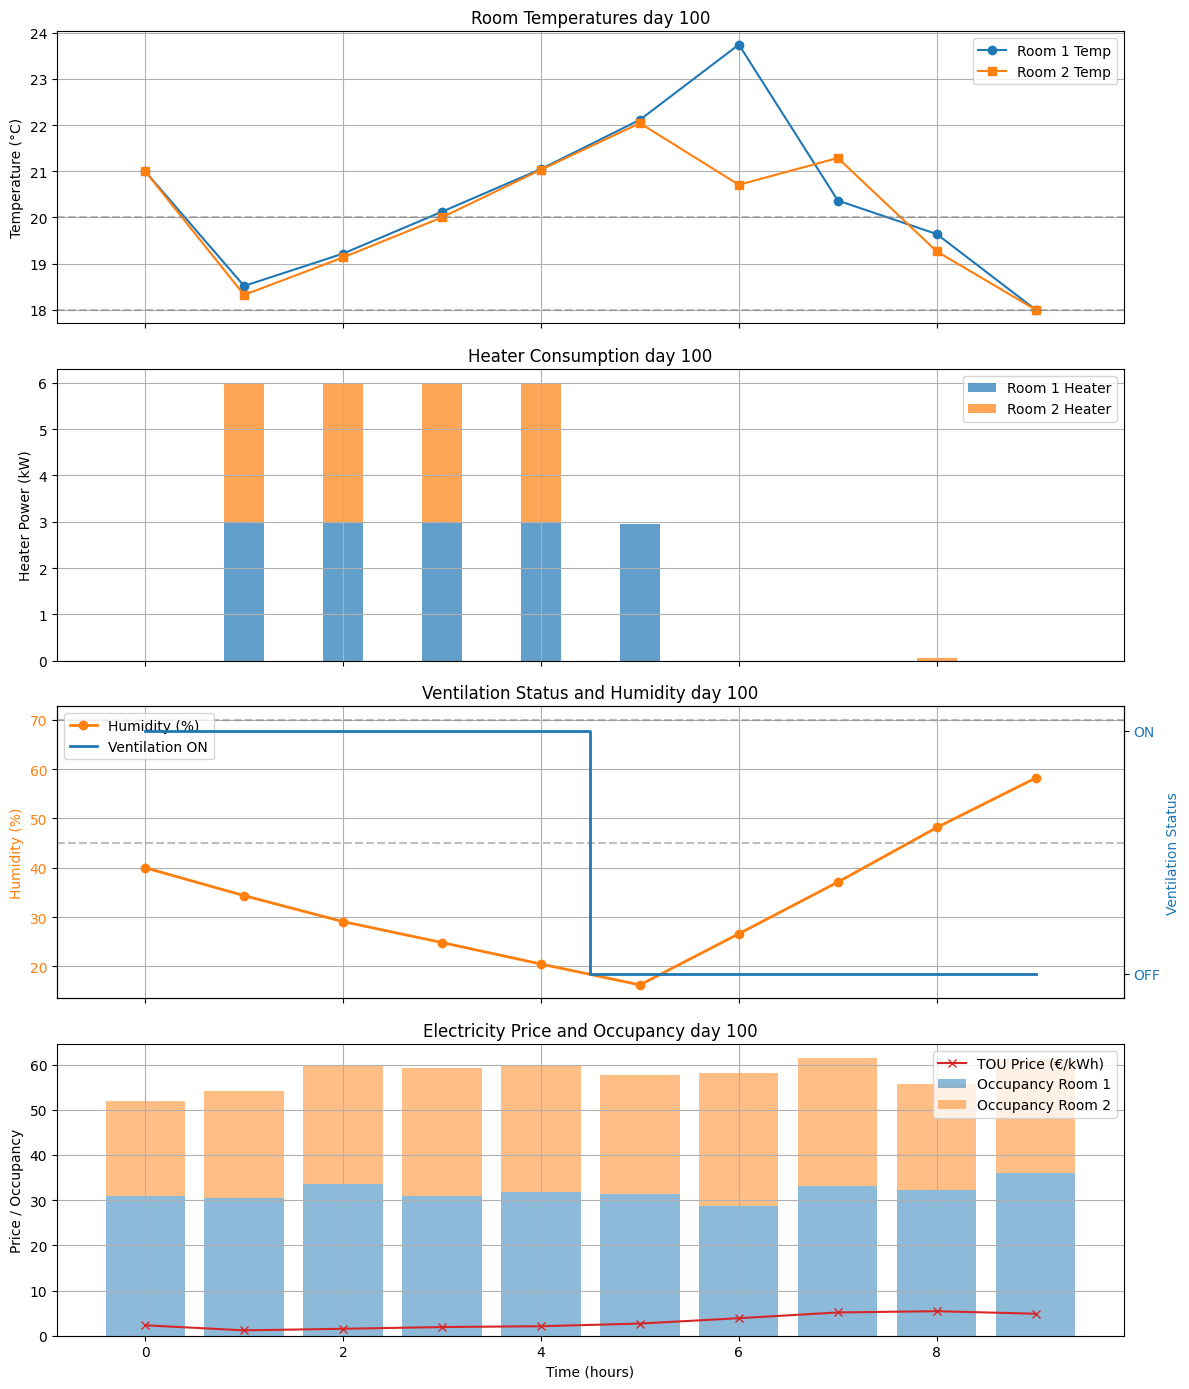

In [73]:
plot_HVAC_results(HVAC_results)

### Analisi Multi-Giorno

In [74]:
# data estraction for every day
T_list = list(model.T)
D_list = list(model.D)
num_timeslots = len(T_list)
num_days = len(D_list)

# concatenate list for every day
all_days_data = {
    "time": [],
    "Temp_r1": [],
    "Temp_r2": [],
    "h_r1": [],
    "h_r2": [],
    "v": [],
    "Hum": [],
    "price": [],
    "Occ_r1": [],
    "Occ_r2": [],
}

# concatenate data for all days
for d in D_list:
    for t in T_list:
        all_days_data["time"].append(d * num_timeslots + t)
        all_days_data["Temp_r1"].append(value(model.T_in[1, t, d]))
        all_days_data["Temp_r2"].append(value(model.T_in[2, t, d]))
        all_days_data["h_r1"].append(value(model.Heat[1, t, d]))
        all_days_data["h_r2"].append(value(model.Heat[2, t, d]))
        all_days_data["v"].append(value(model.Vent[t, d]))
        all_days_data["Hum"].append(value(model.Hum[t, d]))
        all_days_data["price"].append(value(model.prices[d, t]))
        all_days_data["Occ_r1"].append(Occ_r1.iloc[d, t])
        all_days_data["Occ_r2"].append(Occ_r2.iloc[d, t])

In [75]:
def plot_all_days_sequential(all_days_data):
    """
    Plot all the data for all days sequentially in a single figure with 4 subplots:
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(4, 1, figsize=(20, 14), sharex=True)
    
    time = all_days_data["time"]
    
    # Room Temperatures
    axes[0].plot(time, all_days_data["Temp_r1"], label='Room 1 Temp', alpha=0.7, linewidth=0.8)
    axes[0].plot(time, all_days_data["Temp_r2"], label='Room 2 Temp', alpha=0.7, linewidth=0.8)
    axes[0].axhline(18, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(22, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title("Room Temperatures - All Days Sequential")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Heater consumption
    axes[1].fill_between(time, 0, all_days_data["h_r1"], label='Room 1 Heater', alpha=0.6)
    axes[1].fill_between(time, all_days_data["h_r1"], 
                         [h1 + h2 for h1, h2 in zip(all_days_data["h_r1"], all_days_data["h_r2"])], 
                         label='Room 2 Heater', alpha=0.6)
    axes[1].set_ylabel("Heater Power (kW)")
    axes[1].set_title("Heater Consumption")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Ventilation and Humidity
    axes[2].fill_between(time, 0, all_days_data["v"], label='Ventilation ON', 
                         color='tab:blue', alpha=0.3, step='mid')
    axes[2].plot(time, all_days_data["Hum"], label='Humidity (%)', 
                 color='tab:orange', linewidth=0.8)
    axes[2].axhline(45, color='gray', linestyle='--', alpha=0.5)
    axes[2].axhline(70, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_ylabel("Ventilation / Humidity")
    axes[2].set_title("Ventilation Status and Humidity")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Electricity price and total occupancy
    ax3a = axes[3]
    ax3b = ax3a.twinx()
    
    ax3a.plot(time, all_days_data["price"], label='TOU Price (€/kWh)', 
             color='tab:red', linewidth=0.8, alpha=0.7)
    ax3a.set_ylabel("Price (€/kWh)", color='tab:red')
    ax3a.tick_params(axis='y', labelcolor='tab:red')
    
    total_occ = [o1 + o2 for o1, o2 in zip(all_days_data["Occ_r1"], all_days_data["Occ_r2"])]
    ax3b.fill_between(time, 0, total_occ, label='Total Occupancy', 
                     alpha=0.3, color='tab:green')
    ax3b.set_ylabel("Total Occupancy", color='tab:green')
    ax3b.tick_params(axis='y', labelcolor='tab:green')
    
    axes[3].set_xlabel("Time (hours)")
    axes[3].set_title("Electricity Price and Total Occupancy")
    ax3a.grid(True, alpha=0.3)
    
    # Add vertical lines to separate days
    for d in range(1, num_days):
        for ax in axes:
            ax.axvline(d * num_timeslots, color='black', linestyle=':', alpha=0.2, linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

In [76]:
def plot_daily_average_comparison(model):
    """
    Plot day average comparison for room temperatures, heater consumption, ventilation status, and humidity 
    across all days, with specific days highlighted for comparison.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    T_list = list(model.T)
    D_list = list(model.D)
    
    # average calculation for each time step across all days
    avg_data = {
        "Temp_r1": [],
        "Temp_r2": [],
        "h_r1": [],
        "h_r2": [],
        "v": [],
        "Hum": [],
    }
    
    for t in T_list:
        avg_data["Temp_r1"].append(np.mean([value(model.T_in[1, t, d]) for d in D_list]))
        avg_data["Temp_r2"].append(np.mean([value(model.T_in[2, t, d]) for d in D_list]))
        avg_data["h_r1"].append(np.mean([value(model.Heat[1, t, d]) for d in D_list]))
        avg_data["h_r2"].append(np.mean([value(model.Heat[2, t, d]) for d in D_list]))
        avg_data["v"].append(np.mean([value(model.Vent[t, d]) for d in D_list]))
        avg_data["Hum"].append(np.mean([value(model.Hum[t, d]) for d in D_list]))
    
    # select specific days to compare with the average (e.g., first day, middle day, last day)
    days_to_compare = [0, len(D_list)//2, len(D_list)-1]
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
    
    # Room Temperatures
    axes[0].plot(T_list, avg_data["Temp_r1"], label='Room 1 - Average', 
                linewidth=2.5, color='tab:blue', linestyle='-')
    axes[0].plot(T_list, avg_data["Temp_r2"], label='Room 2 - Average', 
                linewidth=2.5, color='tab:orange', linestyle='-')
    
    for d in days_to_compare:
        temp1 = [value(model.T_in[1, t, d]) for t in T_list]
        temp2 = [value(model.T_in[2, t, d]) for t in T_list]
        axes[0].plot(T_list, temp1, alpha=0.3, linestyle='--', label=f'Day {d} R1')
        axes[0].plot(T_list, temp2, alpha=0.3, linestyle='--', label=f'Day {d} R2')
    
    axes[0].axhline(18, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(22, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title("Room Temperatures - Daily Average vs Specific Days")
    axes[0].legend(ncol=2, fontsize=8)
    axes[0].grid(True)
    
    # Heater consumption
    axes[1].plot(T_list, avg_data["h_r1"], label='Room 1 - Average', 
                linewidth=2.5, color='tab:blue')
    axes[1].plot(T_list, avg_data["h_r2"], label='Room 2 - Average', 
                linewidth=2.5, color='tab:orange')
    
    for d in days_to_compare:
        h1 = [value(model.Heat[1, t, d]) for t in T_list]
        h2 = [value(model.Heat[2, t, d]) for t in T_list]
        axes[1].plot(T_list, h1, alpha=0.3, linestyle='--')
        axes[1].plot(T_list, h2, alpha=0.3, linestyle='--')
    
    axes[1].set_ylabel("Heater Power (kW)")
    axes[1].set_title("Heater Consumption - Daily Average")
    axes[1].legend()
    axes[1].grid(True)
    
    # Ventilation
    axes[2].plot(T_list, avg_data["v"], label='Ventilation - Average', 
                linewidth=2.5, color='tab:blue', drawstyle='steps-mid')
    
    for d in days_to_compare:
        v_vals = [value(model.Vent[t, d]) for t in T_list]
        axes[2].plot(T_list, v_vals, alpha=0.3, linestyle='--', drawstyle='steps-mid')
    
    axes[2].set_ylabel("Ventilation ON Probability")
    axes[2].set_title("Ventilation Status - Daily Average")
    axes[2].legend()
    axes[2].grid(True)
    
    # Humidity
    axes[3].plot(T_list, avg_data["Hum"], label='Humidity - Average', 
                linewidth=2.5, color='tab:orange')
    
    for d in days_to_compare:
        hum = [value(model.Hum[t, d]) for t in T_list]
        axes[3].plot(T_list, hum, alpha=0.3, linestyle='--', label=f'Day {d}')
    
    axes[3].axhline(45, color='gray', linestyle='--', alpha=0.5)
    axes[3].axhline(70, color='gray', linestyle='--', alpha=0.5)
    axes[3].set_ylabel("Humidity (%)")
    axes[3].set_xlabel("Time (hours of day)")
    axes[3].set_title("Humidity - Daily Average")
    axes[3].legend(ncol=2, fontsize=8)
    axes[3].grid(True)
    
    plt.tight_layout()
    plt.show()

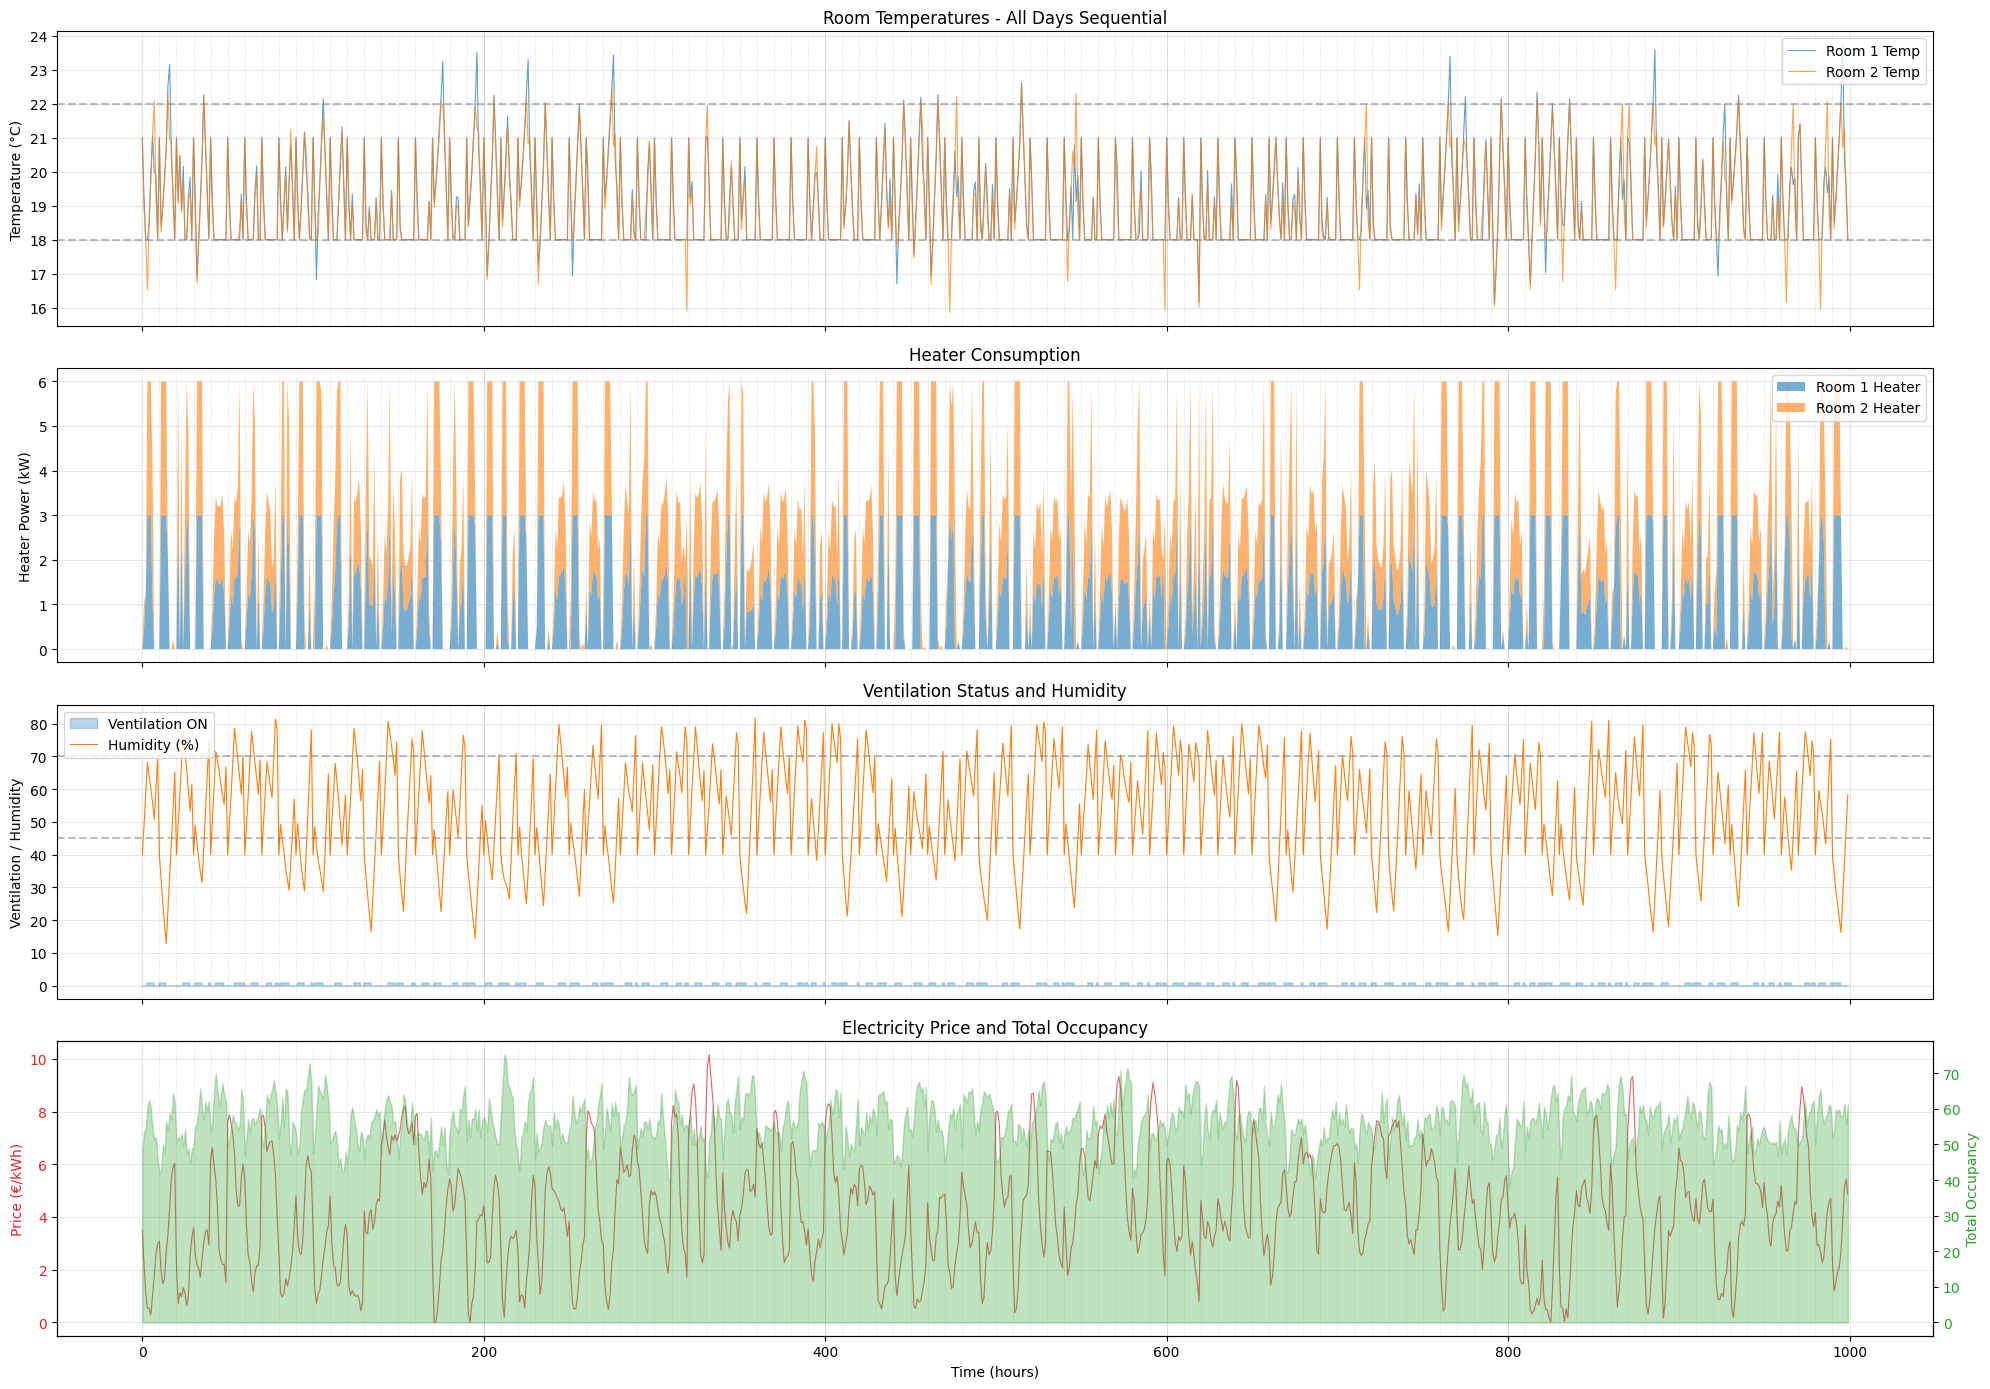

In [77]:
plot_all_days_sequential(all_days_data)

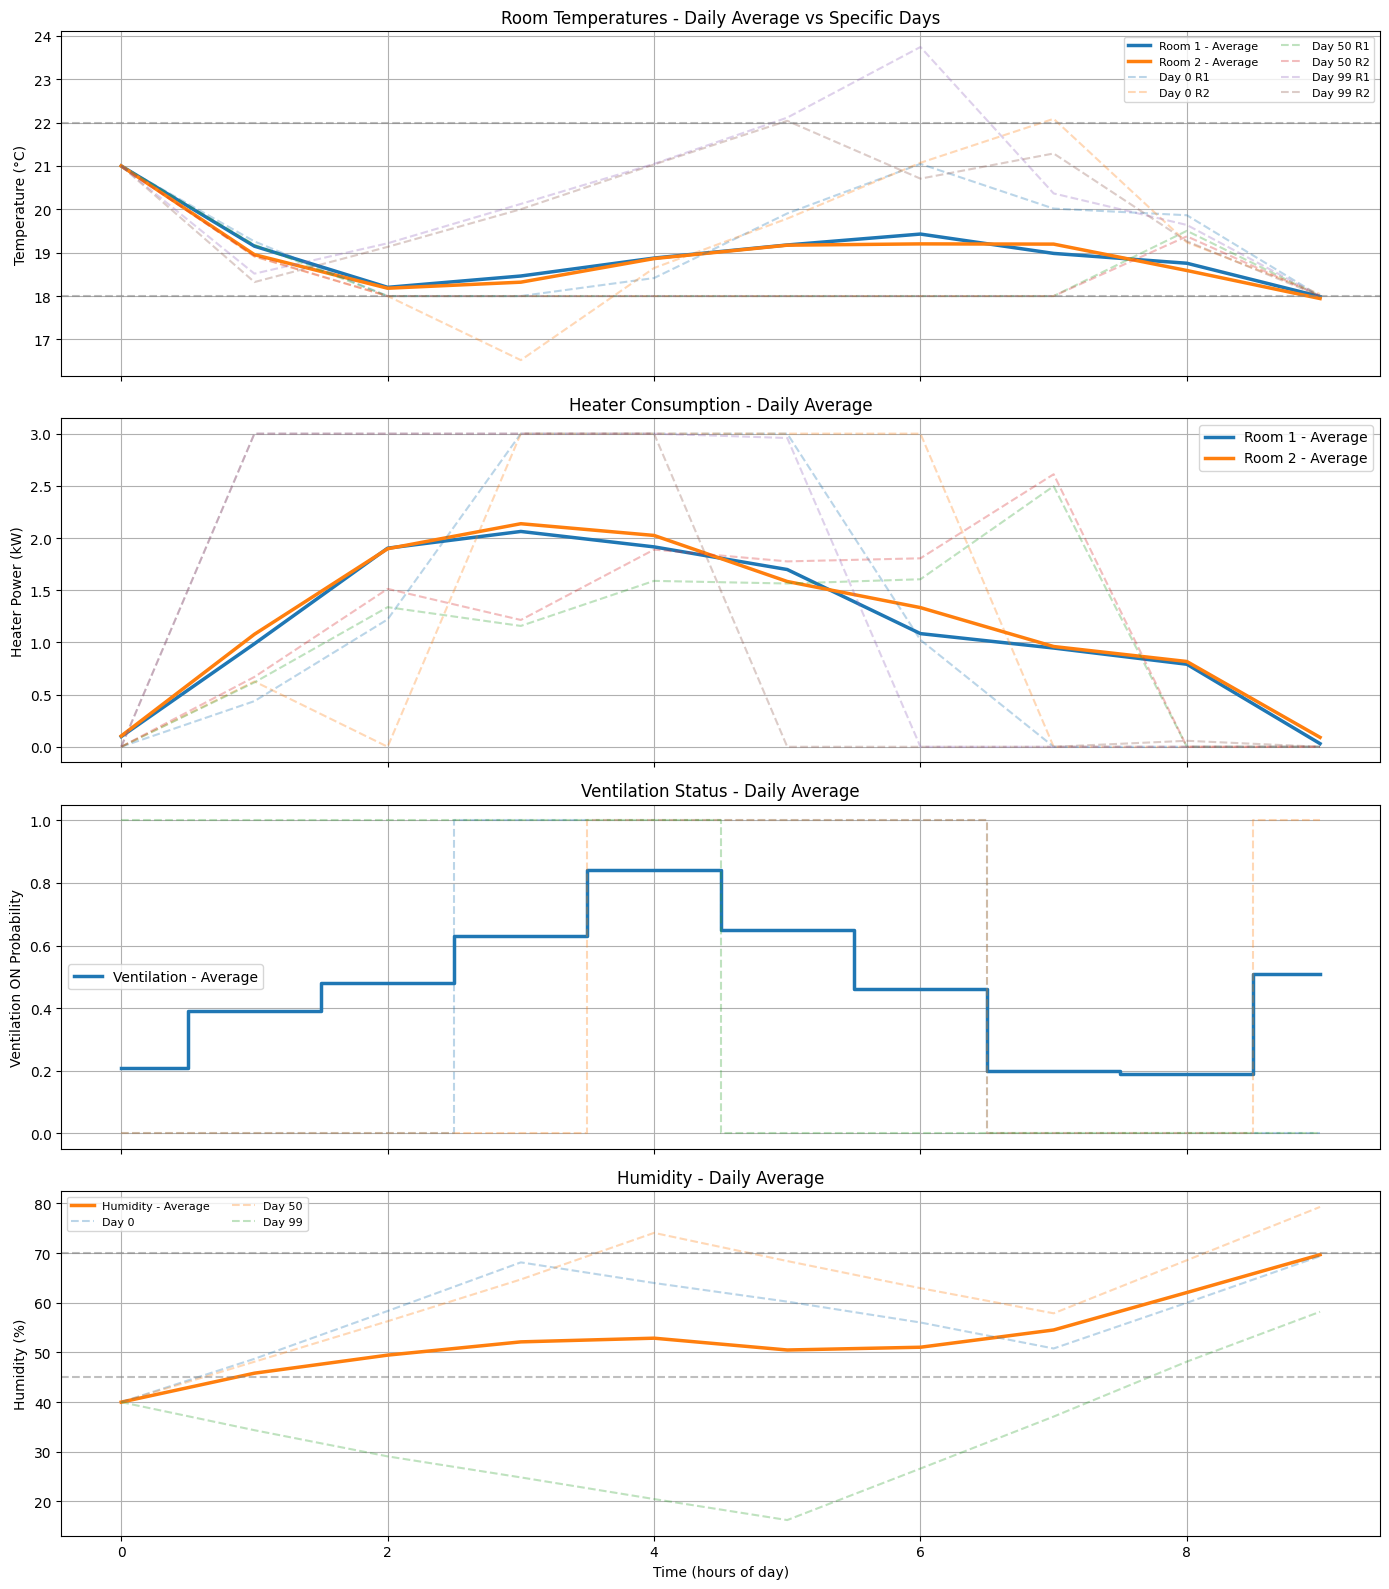

In [78]:
plot_daily_average_comparison(model)

# Part B

## Look ahead

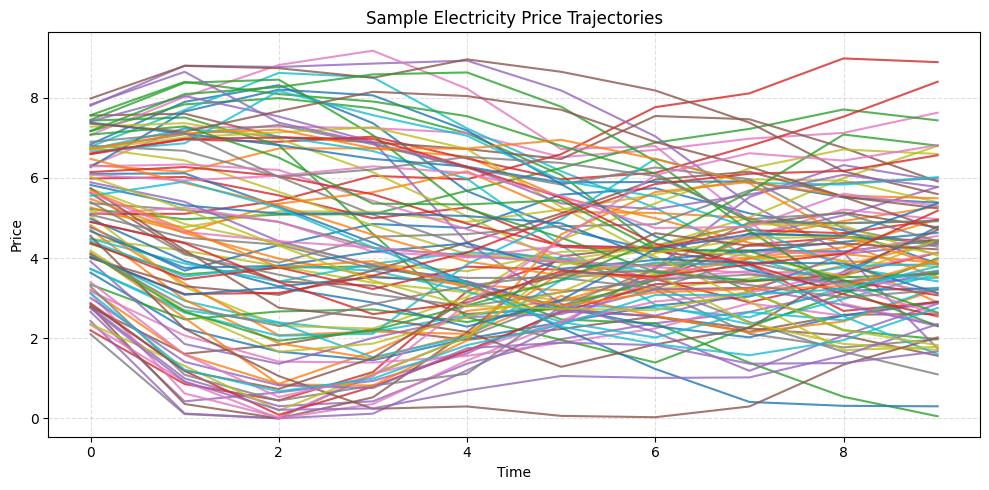

In [79]:
def price_model(current_price, previous_price):
    """
    Price process with dependence on previous prices.
    """
    mean_price = 4
    reversion_strength = 0.12
    price_cap = 12
    price_floor = 0

    mean_reversion = reversion_strength * (mean_price - current_price)
    noise = np.random.normal(0, 0.5)

    next_price = current_price + 0.6 * (current_price - previous_price) + mean_reversion + noise

    # Special handling if price goes negative
    if next_price < 0:
        if np.random.rand() > 0.2:
            next_price = np.random.uniform(0, mean_price * 0.3)

    # Enforce bounds
    return max(min(next_price, price_cap), price_floor)


# -----------------------------
# Example Use: Generate and plot trajectories
# -----------------------------
params = get_fixed_data()
T = int(params['num_timeslots'])

num_paths = 100
all_paths = []

for i in range(num_paths):
    # initialize with current price
    traj = [np.random.uniform(2, 8)]

    for t in range(1, T):
        prev = traj[-1]
        prev_prev = traj[-2] if t > 1 else 6 # arbitrary previous price for t=1
        traj.append(price_model(prev, prev_prev))

    all_paths.append(traj)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 5))

for i, traj in enumerate(all_paths):
    plt.plot(range(T), traj, alpha=0.8, label=f"Path {i+1}")

plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Sample Electricity Price Trajectories")
plt.grid(True, linestyle="--", alpha=0.4)
#plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

import pandas as pd

#pd.DataFrame(all_paths).to_csv("OutOfSamplePriceData.csv", index=False)

In [80]:
price_forecast = {}
def generate_price_forecasts(s,price_current, price_previous):
    for s in range(s):
        for t in range(get_fixed_data['num_timeslots']):
            # Calculate these once
            price= price_model(price_current, price_previous)
            # Store them in a lookup dictionary
            price_forecast[1, t, s] = price
    return price_forecast

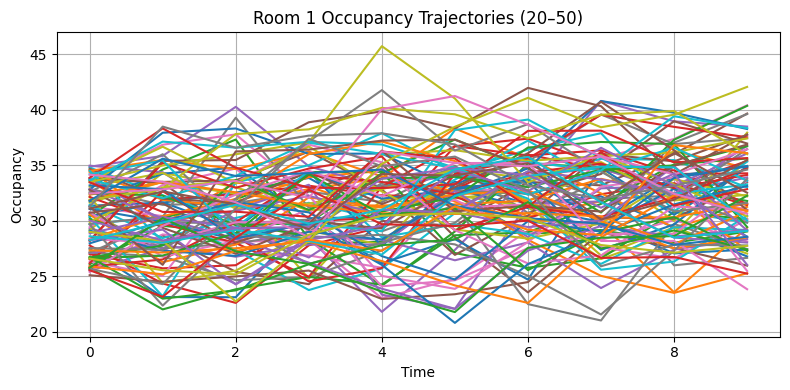

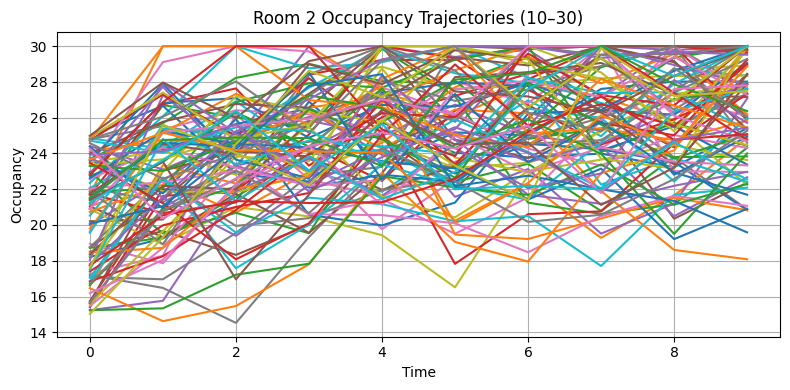

In [81]:
def next_occupancy_levels(r1_current, r2_current):
    """
    Markovian 2-room occupancy update.
    
    Args:
        r1_current (float): Occupancy in Room 1 at time t-1
        r2_current (float): Occupancy in Room 2 at time t-1
    
    Returns:
        (float, float): Occupancies (r1_next, r2_next) at time t
    """

    # ---- Long-run means ----
    mean_r1 = 35.0   # Room 1 is busier
    mean_r2 = 25.0   # Room 2 is less busy

    # ---- Reversion strength (same for both rooms) ----
    rev = 0.25

    # ---- Coupling strength ----
    coupling = 0.1   # weak influence of one room on the other

    # ---- Noise ----
    noise_r1 = np.random.normal(0, 3.0)
    noise_r2 = np.random.normal(0, 2.5)

    # ---- Room 1 update ----
    r1_next = (
        r1_current
        + rev * (mean_r1 - r1_current)
        + coupling * (r2_current - r1_current)
        + noise_r1
    )

    # ---- Room 2 update ----
    r2_next = (
        r2_current
        + rev * (mean_r2 - r2_current)
        + coupling * (r1_current - r2_current)
        + noise_r2
    )

    # ---- Enforce boundaries ----
    r1_next = float(np.clip(r1_next, 20, 50))
    r2_next = float(np.clip(r2_next, 10, 30))

    return r1_next, r2_next



### Example use to generate trajectories


import matplotlib.pyplot as plt

def generate_trajectories(T, num_paths):

    r1_paths = []
    r2_paths = []

    for _ in range(num_paths):
        # Random initial states inside allowed ranges
        r1 = [np.random.uniform(25, 35)]
        r2 = [np.random.uniform(15, 25)]

        for t in range(1, T):
            r1_next, r2_next = next_occupancy_levels(r1[-1], r2[-1])
            r1.append(r1_next)
            r2.append(r2_next)

        r1_paths.append(r1)
        r2_paths.append(r2)

    return r1_paths, r2_paths


def plot_trajectories(r1_paths, r2_paths):
    T = len(r1_paths[0])

    # --- Room 1 ---
    plt.figure(figsize=(8,4))
    for traj in r1_paths:
        plt.plot(traj)
    plt.title("Room 1 Occupancy Trajectories (20–50)")
    plt.xlabel("Time")
    plt.ylabel("Occupancy")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Room 2 ---
    plt.figure(figsize=(8,4))
    for traj in r2_paths:
        plt.plot(traj)
    plt.title("Room 2 Occupancy Trajectories (10–30)")
    plt.xlabel("Time")
    plt.ylabel("Occupancy")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    r1, r2 = generate_trajectories(T=10, num_paths=100)
    plot_trajectories(r1, r2)

#import pandas as pd

#pd.DataFrame(r1).to_csv("OutOfSampleOccupancyRoom1.csv", index=False)
#pd.DataFrame(r2).to_csv("OutOfSampleOccupancyRoom2.csv", index=False)

In [86]:
occupancy_forecasts = {}
def generate_occupancy_forecasts(s, num_timeslots, initial_occ):
    occupancy_data = {}
    for s in range(s):
        # Start each scenario with the current real-time state
        curr_o1, curr_o2 = initial_occ # [Occ_r1, Occ_r2]
        for t in range(num_timeslots):
            # Calculate next state based on current state
            occ1, occ2 = next_occupancy_levels(curr_o1, curr_o2)
            
            # Store
            occupancy_data[1, t, s] = occ1
            occupancy_data[2, t, s] = occ2
            
            # Update for next iteration
            curr_o1, curr_o2 = occ1, occ2
    return occupancy_data
occ_dict = generate_occupancy_forecasts(s, num_timeslots, initial_occ=[0,0])

## Adding Variables, Parameters and Sets

In [94]:
# Variables
# Create Pyomo model
model = ConcreteModel()
day = 0
s= 4
# Sets 
model.R = Set(initialize=[1, 2])  # Rooms
model.T = Set(initialize=range(data_fixed['num_timeslots'])) #Time steps
#model.D = Set(initialize=range(Occ_r1.shape[0])) # Days (for occupancy data)
#model.TD = model.T * model.D # Time-Day combinations
#model.RTD = model.R*model.T*model.D # Room-Time-Day combinations
model.S = Set(initialize=range(s)) #Scenarios (for future use in Task 2)
model.RTS = model.R*model.T*model.S # Room-Time-Scenario combinations
model.TS = model.T*model.S # Time-Scenario combinations

#Parameters
model.Pr = Param(initialize=data_fixed['heating_max_power']) # Maximum heating power (kW)
model.Zexch = Param(initialize=data_fixed['heat_exchange_coeff']) # Heat exchange coefficient between rooms
model.Zconv = Param(initialize=data_fixed['heating_efficiency_coeff']) # Heating efficiency
model.Zloss = Param(initialize=data_fixed['thermal_loss_coeff']) # Thermal loss coefficient
model.Zcool = Param(initialize=data_fixed['heat_vent_coeff']) # Ventilation cooling effect
model.Zocc = Param(initialize=data_fixed['heat_occupancy_coeff']) # Occupancy
model.Tmin = Param(initialize=data_fixed['temp_min_comfort_threshold']) # Lower threshold for Overrule heater activation
model.Tok = Param(initialize=data_fixed['temp_OK_threshold']) # Temperature above which the Overrule controller is deactived
model.Thigh = Param(initialize=data_fixed['temp_max_comfort_threshold']) # Hard upper limit: when exceeded, heater must be OFF
model.Hhigh = Param(initialize=data_fixed['humidity_threshold']) # Humidity threshold above which overrule controller forces ventilation ON (%)
model.Pvent = Param(initialize=data_fixed['ventilation_power']) # Electrical power consumption of ventilation when ON (kW)
model.Hocc = Param(initialize=data_fixed['humidity_occupancy_coeff']) # Degrees of humidity increase per hour per person
model.Hvent = Param(initialize=data_fixed['humidity_vent_coeff']) # Degrees of humidity decrease per hour that ventilation is ON
model.Tout = Param(model.T, initialize={t: data_fixed['outdoor_temperature'][t] for t in model.T}) # Outdoor temperature (°C)
model.O = Param(model.RTS, initialize = occ_dict) # Occupancy forecasts for each room, time, and scenario
model.prices = Param(model.TS, initialize=price_forecast) # Electricity price forecasts
model.pi = Param(model.S, initialize= 1/s)

# Variables
model.Vent = Var(model.TS, domain=Binary) # Ventilation ON/OFF
model.Uon = Var(model.TS, domain=Binary) # Ventilation start-up
model.Uoff = Var(model.TS, domain=Binary) # Ventilation shut-down
model.Heat = Var(model.RTS, domain=NonNegativeReals, bounds=(0, model.Pr)) # Heating power (kW)
model.w = Var(model.RTS, domain=Binary) # T is higher thatn Tok
model.u = Var(model.RTS, domain=Binary) # T is lower than Tlow
model.z = Var(model.RTS, domain=Binary) # T is lower than Tok
model.y = Var(model.RTS, domain=Binary) # T is higher than Thigh
model.T_in = Var(model.RTS, domain=NonNegativeReals) # Indoor temperature (°C)
model.Hum = Var(model.TS, domain=NonNegativeReals) # Indoor humidity (%)


## Adding Constraints

In [88]:
#Constraint of room temperature and humidity dynamics for room and room 2

# The rule only accepts (model, r, t, s) because the Constraint is indexed by model.RTS
def room_thermal_balance_rule(model, r, t, s):
    if t == 0:
        return model.T_in[r, t, s] == data_fixed['initial_temperature']
    
    t_prev = t - 1
    other_r = 2 if r == 1 else 1
    
    # Access the pre-calculated Param directly
    current_occ = model.O[r, t_prev, s]

    return model.T_in[r, t, s] == (
        model.T_in[r, t_prev, s] 
        + model.Zexch * (model.T_in[other_r, t_prev, s] - model.T_in[r, t_prev, s]) 
        + model.Zloss * (model.Tout[t_prev] - model.T_in[r, t_prev, s])
        + model.Zconv * model.Heat[r, t_prev, s] 
        - model.Zcool * model.Vent[t_prev, s]
        + model.Zocc * current_occ
    )



# Pre-calculate humidity occupancy
hum_occ_dict = {}
for d in range(s):
    for t in range(num_timeslots):
        hum_occ_dict[t, d] = Occ_r1.iloc[d, t] + Occ_r2.iloc[d, t]

model.Hum_Occ = Param(model.T, model.S, initialize=hum_occ_dict)

def humidity_balance_rule(model, t, s): # Note: changed 'd' to 's' for consistency
    if t == 0:
        return model.Hum[t, s] == data_fixed['initial_humidity']
    
    t_prev = t - 1
    return model.Hum[t, s] == (
        model.Hum[t_prev, s]
        - model.Hvent * model.Vent[t_prev, s]
        + model.Hocc * model.Hum_Occ[t_prev, s] # Use the Param
    )

# Apply the rule to the model across all time steps
model.Temp_Room_Dynamics = Constraint(model.RTS, rule=room_thermal_balance_rule)
model.Hum_Room_Dynamics = Constraint(model.TS, rule=humidity_balance_rule)

#----------------------------------------------------------------------------------------------------------------------------


# Max Temperature when temperature is too low 
def max_temp_low_rule(block):

    # M is a large constant, larger than any possible temperature difference
    M = 100 
    m = block.model()

    # Constraint to force u = 1 if T_in <= Tmin
    def u_binary_logic_rule(block, r, t, s):
        return m.T_in[r, t, s] >= m.Tmin - M * m.u[r, t, s]
    block.u_logic = Constraint(m.RTS, rule=u_binary_logic_rule)

    # Force Heat to Max if w = 1
    def low_temp_heat_rule(block, r, t, s):
        return m.T_in[r, t, s] >= m.Tok - M * (1 - m.w[r, t, s])
    block.low_temp_heat = Constraint(m.RTS, rule=low_temp_heat_rule)

    # cannot have both u and w active at the same time
    def u_w_exclusivity_rule(block, r, t, s):    
        # Skip the first time step (initial condition)
        if t == m.T.first():
            m.u[r, t, s].fix(0)  # Force u to be 0 at the first time step
            m.w[r, t, s].fix(0)  # Force w to be 0 at the first time step
            return Constraint.Skip # Skip because initialized conditions are within Tlow and THigh at the first time step
        
        # Define the previous time step
        t_prev = t - 1

        return m.u[r, t, s] >= m.u[r,t_prev, s] - m.w[r, t, s]
    block.u_w_exclusivity = Constraint(m.RTS, rule=u_w_exclusivity_rule)

    #Set P to P max 
    def Set_max_power_rule(block, r, t, s):
        return m.Heat[r, t, s] >= m.Pr * m.u[r, t, s]
    block.Set_max_power = Constraint(m.RTS, rule=Set_max_power_rule)

    
model.set_max_temp_rule = Block(rule=max_temp_low_rule)

#-----------------------------------------------------------------------------------------------------------------------------
def set_power_off_rule(block):
    # M is a large constant (Big-M)
    M = 100 
    m = block.model()

    # Constraint to force y = 1 if T_in >= Thigh
    # If T_in > Thigh, then y must be 1 to satisfy: T_in <= Thigh + M*y
    def y_binary_logic_rule(block, r, t, s):
        return m.T_in[r, t, s] <= m.Thigh + M * m.y[r, t, s]
    block.y_logic = Constraint(m.RTS, rule=y_binary_logic_rule)

    # Force Heat to 0 if y = 1
    # If y = 1, Heat <= Pr * (1 - 1) => Heat <= 0
    # If y = 0, Heat <= Pr * (1 - 0) => Heat <= Pr (normal operation)
    def Set_power_off_rule(block, r, t, s):
        return m.Heat[r, t, s] <= m.Pr * (1 - m.y[r, t, s])
    block.Set_power_off = Constraint(m.RTS, rule=Set_power_off_rule)

# Apply the block to the model
model.set_power_off_rule = Block(rule=set_power_off_rule)

#-----------------------------------------------------------------------------------------------------------------------------
def set_vent_on_rule(model,t,s):
    # Force Vent ON if Hum >= Hhigh
    M = 100
    return model.Hum[t, s] <= model.Hhigh + M * model.Vent[t, s]

model.vent_on_rule = Constraint(model.TS, rule=set_vent_on_rule)
#-----------------------------------------------------------------------------------------------------------------------------
#Operational constraints for ventilation system
def on_off_limit_rule(model, t, s):
    return model.Uon[t, s] + model.Uoff[t, s] <= 1
model.on_off_limit = Constraint(model.TS, rule=on_off_limit_rule)

# Constraint 2: U_off <= e
def off_le_e_rule(model, t, s):
    return model.Uoff[t, s] <=1 - model.Vent[t, s]
model.off_le_e = Constraint(model.TS, rule=off_le_e_rule)

# Constraint 3: U_on <= 1 - e
def on_le_one_minus_e_rule(model, t, s):
    return model.Uon[t, s] <= 1 - model.Vent[t, s]
model.on_le_one_minus_e = Constraint(model.TS, rule=on_le_one_minus_e_rule)
#-----------------------------------------------------------------------------------------------------------------------------
### check that this funciton is working
def min_up_time_ventilation_rule(model, t, s):
    # We can't check 't-1' for the very first hour
    #if t == model.T.first():
        #return Constraint.Skip
    
    # Define the 'Up-Time' duration
    L = 3 
    
    # If we are too close to the end of the day to look L steps ahead,
    # we adjust the summation range to not exceed the time set.
    remaining_steps = [k for k in range(t, t + L) if k <= model.T.last()]
    #if t = 0 assume ventilation was off in the previous hour
    v_prev = model.Vent[t-1, s] if t > model.T.first() else 0

    # Logic: Sum of future states >= duration * (Current - Previous)
    return sum(model.Vent[k, s] for k in remaining_steps) >= \
           len(remaining_steps) * (model.Vent[t, s] - v_prev)

model.min_vent_on = Constraint(model.TS, rule=min_up_time_ventilation_rule)
    

In [90]:
def heater_non_anticipativity_rule(model, r, s1, s2):
    # Only compare distinct scenarios where s1 < s2 to avoid redundant checks
    if s1 >= s2:
        return Constraint.Skip
    
    # Return the symbolic equality expression
    return model.Heat[r, 0, s1] == model.Heat[r, 0, s2]

# Add to model, indexed by Rooms, Scenarios, and Scenarios
model.heater_non_anticipativity = Constraint(model.R, model.S, model.S, rule=heater_non_anticipativity_rule)

In [91]:
def vent_non_anticipativity_rule(model, s1, s2):
    if s1 >= s2:
        return Constraint.Skip
    
    # Return the symbolic equality expression
    return model.Vent[0, s1] == model.Vent[0, s2]

# Add to model, indexed only by Scenarios
model.vent_non_anticipativity = Constraint(model.S, model.S, rule=vent_non_anticipativity_rule)

## Objective Function

In [96]:
# Assuming you have defined probabilities pi[s] for each scenario
def objective_rule(model):
    # Sum of expected costs across all scenarios s in set S
    return sum(
        model.pi[s] * sum(
            model.prices[t, s] * (
                sum(model.Heat[r, t, s] for r in model.R) + 
                model.Vent[t, s] * model.Pvent
            ) for t in model.T
        ) for s in model.S
    )

model.obj = Objective(rule=objective_rule, sense=minimize)

'pyomo.core.base.objective.ScalarObjective'>) on block unknown with a new
Component (type=<class 'pyomo.core.base.objective.AbstractScalarObjective'>).
This is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
ERROR: Rule failed when generating expression for Objective obj with index
None: ValueError: Error retrieving immutable Param value (prices[(0, 0)]):
            The Param value is undefined and no default value is specified.
ERROR: Constructing component 'obj' from data=None failed:
        ValueError: Error retrieving immutable Param value (prices[(0, 0)]):
    	The Param value is undefined and no default value is specified.


ValueError: Error retrieving immutable Param value (prices[(0, 0)]):
	The Param value is undefined and no default value is specified.